In [14]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import os 
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [15]:
df = pd.read_csv('../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nTotal kolom: {len(df.columns)}")

Shape: (225745, 79)

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Total kolom: 79


In [16]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tidak ada missing values")

print("\n=== Infinite Values ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print(inf_counts[inf_counts > 0] if inf_counts.any() else "Tidak ada infinite values")

print("\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum():,}")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

=== Missing Values ===
Flow Bytes/s    4
dtype: int64

=== Infinite Values ===
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64

=== Duplicate Rows ===
Duplicates: 2,633

=== Data Types ===
int64      54
float64    24
object      1
Name: count, dtype: int64


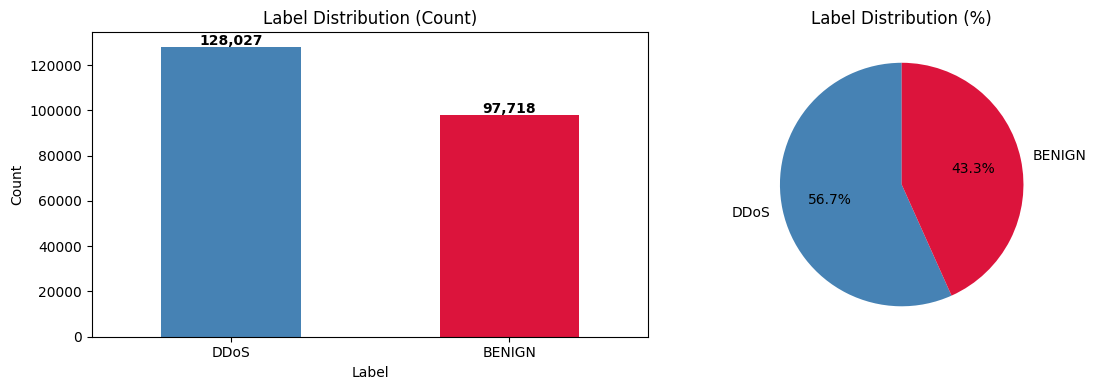

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['steelblue', 'crimson']

df['Label'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors
)
axes[0].set_title('Label Distribution (Count)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['Label'].value_counts()):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

df['Label'].value_counts(normalize=True).mul(100).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=colors, startangle=90
)
axes[1].set_title('Label Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

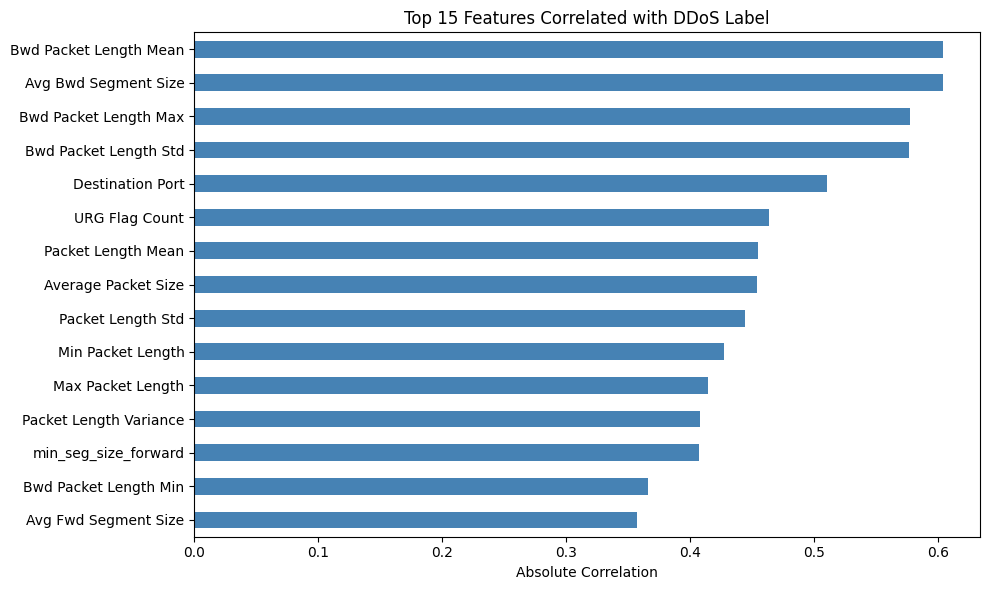


Top 15 features:
Bwd Packet Length Mean   0.6033
Avg Bwd Segment Size     0.6033
Bwd Packet Length Max    0.5773
Bwd Packet Length Std    0.5762
Destination Port         0.5098
URG Flag Count           0.4632
Packet Length Mean       0.4543
Average Packet Size      0.4535
Packet Length Std        0.4437
Min Packet Length        0.4274
Max Packet Length        0.4144
Packet Length Variance   0.4081
min_seg_size_forward     0.4073
Bwd Packet Length Min    0.3657
Avg Fwd Segment Size     0.3569
dtype: float64


In [18]:
df['label_encoded'] = (df['Label'] == 'DDoS').astype(int)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('label_encoded')

correlations = df[numeric_cols].corrwith(
    df['label_encoded']
).abs().sort_values(ascending=False)

correlations.head(15).plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.title('Top 15 Features Correlated with DDoS Label')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(correlations.head(15))

Top 4 features: ['Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Bwd Packet Length Max', 'Bwd Packet Length Std']


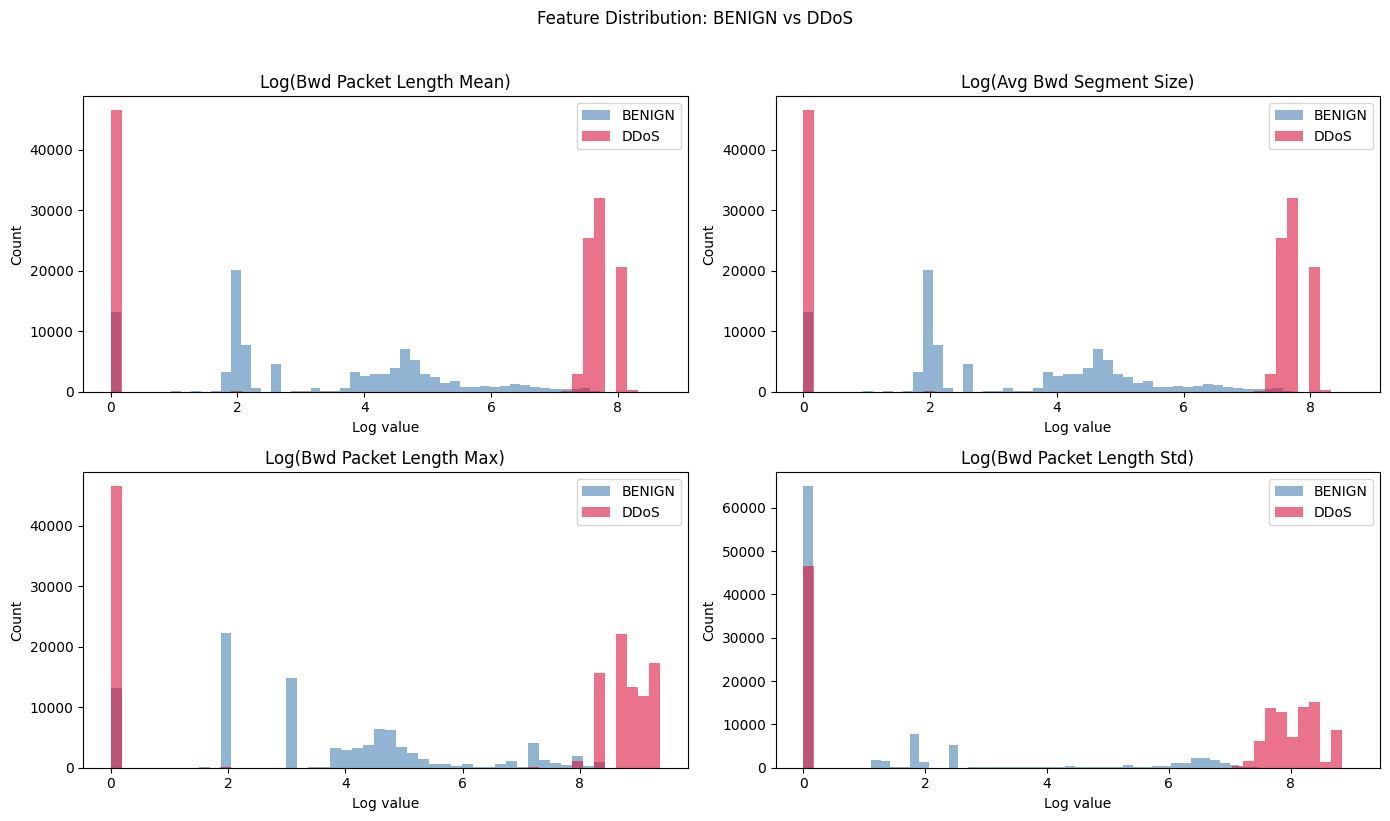

In [19]:
top_features = correlations.head(4).index.tolist()
print(f"Top 4 features: {top_features}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, feature in zip(axes.flatten(), top_features):
    for label, color in zip(['BENIGN', 'DDoS'], ['steelblue', 'crimson']):
        data = df[df['Label'] == label][feature].clip(lower=0)
        data = np.log1p(data)
        ax.hist(data, bins=50, alpha=0.6, label=label, color=color)
    ax.set_title(f'Log({feature})')
    ax.legend()
    ax.set_xlabel('Log value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distribution: BENIGN vs DDoS', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
df = df.drop_duplicates()
print(f"Setelah drop duplicates: {len(df):,} rows")

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df.dropna()
print(f"Setelah drop NaN/Inf: {len(df):,} rows")

print(f"\nMissing values tersisa: {df.isnull().sum().sum()}")
print(f"Infinite values tersisa: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Duplicates tersisa: {df.duplicated().sum()}")

Setelah drop duplicates: 223,112 rows
Setelah drop NaN/Inf: 223,082 rows

Missing values tersisa: 0
Infinite values tersisa: 0
Duplicates tersisa: 0


In [21]:
top_features = correlations.head(20).index.tolist()

df['pkt_len_ratio'] = df['Bwd Packet Length Mean'] / (df['Fwd Packet Length Mean'] + 1)
df['flow_rate'] = df['Flow Bytes/s'] / (df['Flow Duration'] + 1)
df['bwd_fwd_ratio'] = df['Bwd Packets/s'] / (df['Flow Packets/s'] + 1)

engineered_features = ['pkt_len_ratio', 'flow_rate', 'bwd_fwd_ratio']
final_features = top_features + engineered_features

print(f"Total features: {len(final_features)}")
print(f"\nFeature list:")
for f in final_features:
    print(f"  - {f}")

Total features: 23

Feature list:
  - Bwd Packet Length Mean
  - Avg Bwd Segment Size
  - Bwd Packet Length Max
  - Bwd Packet Length Std
  - Destination Port
  - URG Flag Count
  - Packet Length Mean
  - Average Packet Size
  - Packet Length Std
  - Min Packet Length
  - Max Packet Length
  - Packet Length Variance
  - min_seg_size_forward
  - Bwd Packet Length Min
  - Avg Fwd Segment Size
  - Fwd Packet Length Mean
  - Fwd Packet Length Max
  - Subflow Fwd Bytes
  - Total Length of Fwd Packets
  - Bwd IAT Total
  - pkt_len_ratio
  - flow_rate
  - bwd_fwd_ratio


In [ ]:
X = df[final_features].copy()
y = df['label_encoded'].copy()

X.replace([np.inf, -np.inf], np.nan, inplace=True)

inf_check = np.isinf(X).sum()
print("Infinite values per kolom:")
print(inf_check[inf_check > 0] if inf_check.any() else "Bersih")

nan_check = X.isnull().sum()
print("\nNaN values per kolom:")
print(nan_check[nan_check > 0] if nan_check.any() else "Bersih")

X = X.dropna()
y = y[X.index]

print(f"\nFinal rows: {len(X):,}")

for col in X.columns:
    q99 = X[col].quantile(0.99)
    q01 = X[col].quantile(0.01)
    X[col] = X[col].clip(lower=q01, upper=q99)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=final_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size : {len(X_test):,}")
print(f"\nTrain label distribution:")
print(y_train.value_counts())

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

joblib.dump(scaler, '../data/processed/scaler.pkl')
joblib.dump(final_features, '../data/processed/features.pkl')

print("\nData saved ke data/processed/")

Infinite values per kolom:
Bersih

NaN values per kolom:
flow_rate    2
dtype: int64

Final rows: 223,080
Train size: 178,464
Test size : 44,616

Train label distribution:
label_encoded
1    102411
0     76053
Name: count, dtype: int64

Data saved ke data/processed/


In [30]:
# Jalankan ini di Python
import pandas as pd
import numpy as np

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train_normal = X_train[y_train == 0]
X_test_benign = X_test[y_test == 0]
X_test_ddos = X_test[y_test == 1]

print("=== Statistik per class ===")
print(f"\nTrain BENIGN mean: {X_train_normal.mean().mean():.4f}")
print(f"Test BENIGN mean : {X_test_benign.mean().mean():.4f}")
print(f"Test DDoS mean   : {X_test_ddos.mean().mean():.4f}")

print(f"\nTrain BENIGN std: {X_train_normal.std().mean():.4f}")
print(f"Test BENIGN std : {X_test_benign.std().mean():.4f}")
print(f"Test DDoS std   : {X_test_ddos.std().mean():.4f}")

print("\n=== Overlap check — top 5 features ===")
features = X_train.columns.tolist()
for col in features[:5]:
    benign_mean = X_test_benign[col].mean()
    ddos_mean = X_test_ddos[col].mean()
    print(f"{col:35s} BENIGN: {benign_mean:.4f} | DDoS: {ddos_mean:.4f}")

=== Statistik per class ===

Train BENIGN mean: 7099.7733
Test BENIGN mean : 7294.6433
Test DDoS mean   : 37.8148

Train BENIGN std: 36357.5797
Test BENIGN std : 36947.2300
Test DDoS std   : 2573.0147

=== Overlap check — top 5 features ===
Bwd Packet Length Mean              BENIGN: 0.0147 | DDoS: 0.7183
Avg Bwd Segment Size                BENIGN: 0.0147 | DDoS: 0.7183
Bwd Packet Length Max               BENIGN: 0.0342 | DDoS: 0.7733
Bwd Packet Length Std               BENIGN: 0.0364 | DDoS: 0.8640
Destination Port                    BENIGN: 20668.3619 | DDoS: 2.4902
